In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [2]:
# Load the dataset directly from the UCI repository URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
# The dataset is separated by semicolons, not commas
wine_data = pd.read_csv(url, sep=';')

In [4]:
# 2. Initial Exploration
print("--- Dataset Shape ---")
print(wine_data.shape)

print("\n--- First 5 Rows ---")
print(wine_data.head())

print("\n--- Statistical Summary ---")
print(wine_data.describe())

print("\n--- Missing Values ---")
print(wine_data.isnull().sum())

--- Dataset Shape ---
(4898, 12)

--- First 5 Rows ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.

### EDA

#### Target  Variable Distribution (Quality)

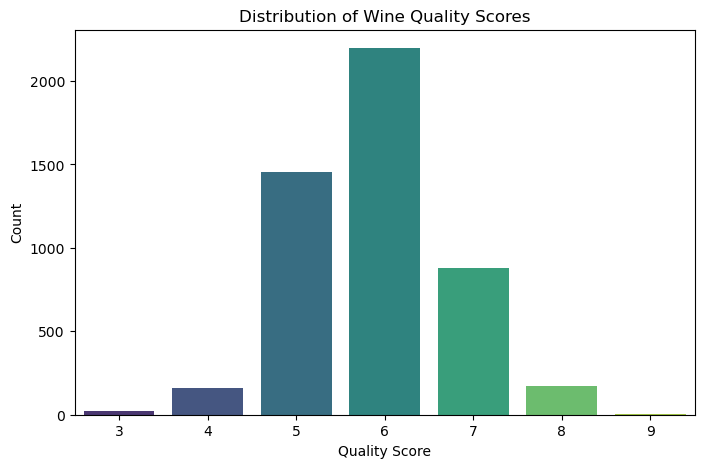

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=wine_data, palette='viridis')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

- The distribution is approximately bell-shaped and centered around 6, with a slight imbalance(mildly skewed)
- The target classes are imbalanced!(Scores 5 and 6 dominate, while scores 3, 4, 8, and 9 are rare)

Most wines are rated around average quality, especially 5 and 6. Very bad and very excellent wines are rare. The distribution is unimodal and bell-like, but not truly normal because the target is ordinal and bounded. Skewness is weak; I would not strongly call it left-skewed. The biggest practical issue is class imbalance, especially for rare scores like 3, 4, 8, and 9.

#### Correlation Heatmap

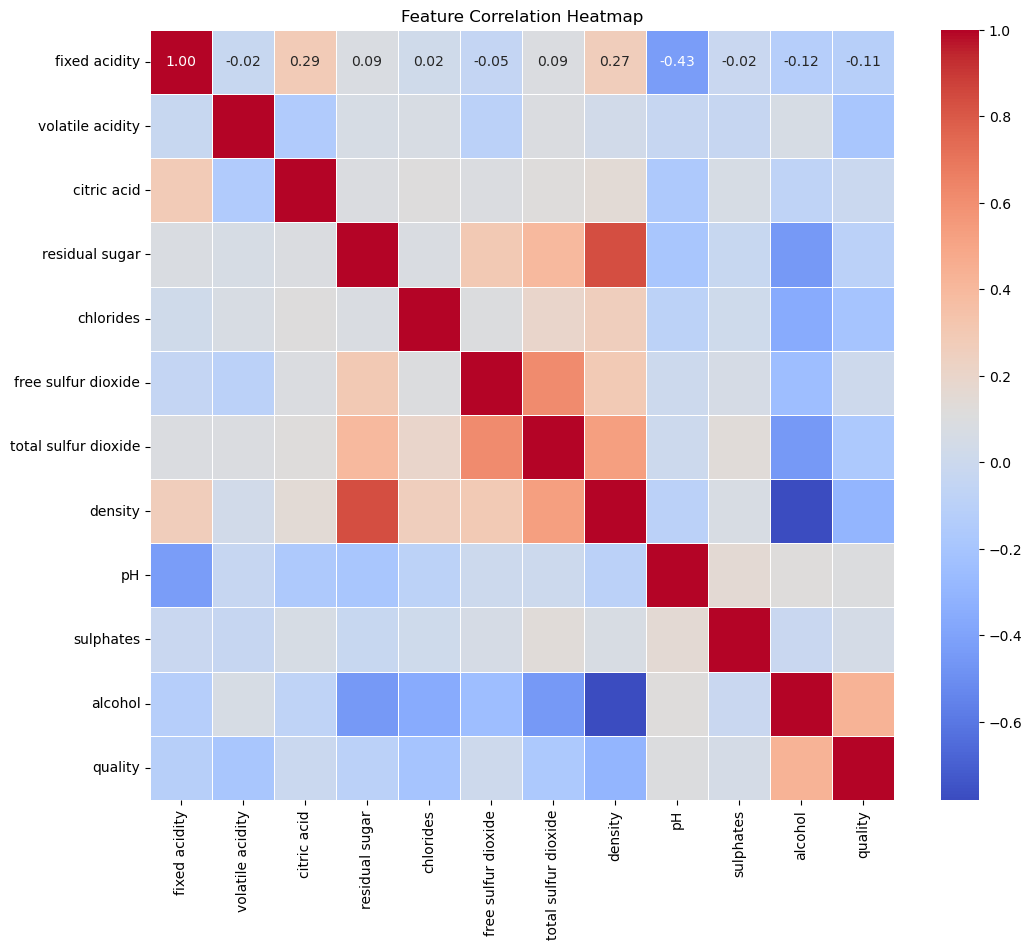

In [14]:
plt.figure(figsize=(12, 10))
correlation_matrix = wine_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [15]:
correlation_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.022697,0.289181,0.089021,0.023086,-0.049396,0.091070,0.265331,-0.425858,-0.017143,-0.120881,-0.113663
volatile acidity,-0.022697,1.000000,-0.149472,0.064286,0.070512,-0.097012,0.089261,0.027114,-0.031915,-0.035728,0.067718,-0.194723
citric acid,0.289181,-0.149472,1.000000,0.094212,0.114364,0.094077,0.121131,0.149503,-0.163748,0.062331,-0.075729,-0.009209
residual sugar,0.089021,0.064286,0.094212,1.000000,0.088685,0.299098,0.401439,0.838966,-0.194133,-0.026664,-0.450631,-0.097577
chlorides,0.023086,0.070512,0.114364,0.088685,1.000000,0.101392,0.198910,0.257211,-0.090439,0.016763,-0.360189,-0.209934
free sulfur dioxide,-0.049396,-0.097012,0.094077,0.299098,0.101392,1.000000,0.615501,0.294210,-0.000618,0.059217,-0.250104,0.008158
total sulfur dioxide,0.091070,0.089261,0.121131,0.401439,0.198910,0.615501,1.000000,0.529881,0.002321,0.134562,-0.448892,-0.174737
density,0.265331,0.027114,0.149503,0.838966,0.257211,0.294210,0.529881,1.000000,-0.093591,0.074493,-0.780138,-0.307123
pH,-0.425858,-0.031915,-0.163748,-0.194133,-0.090439,-0.000618,0.002321,-0.093591,1.000000,0.155951,0.121432,0.099427
sulphates,-0.017143,-0.035728,0.062331,-0.026664,0.016763,0.059217,0.134562,0.074493,0.155951,1.000000,-0.017433,0.053678


In [17]:
# Extract and Sort Correlation with the Target Variable
print("\n--- Correlation with 'quality' (Sorted) ---")
target_corr = correlation_matrix['quality'].sort_values(ascending=False)
print(target_corr)


--- Correlation with 'quality' (Sorted) ---
quality                 1.000000
alcohol                 0.435575
pH                      0.099427
sulphates               0.053678
free sulfur dioxide     0.008158
citric acid            -0.009209
residual sugar         -0.097577
fixed acidity          -0.113663
total sulfur dioxide   -0.174737
volatile acidity       -0.194723
chlorides              -0.209934
density                -0.307123
Name: quality, dtype: float64


- Alcohol shows the strongest positive correlation with wine quality, suggesting that higher-alcohol wines tend to receive better quality scores
- density appears to be one of the strongest negative relationships with quality
- Wines with higher chloride levels tend to receive lower quality scores
- Higher volatile acidity tends to be associated with lower quality

Some variables are strongly connected to each other:

- alcohol vs density
- residual sugar vs density
- free sulfur dioxide vs total sulfur dioxide
- fixed acidity vs pH
- fixed acidity vs citric acid
- residual sugar vs total sulfur dioxide
- density vs residual sugar

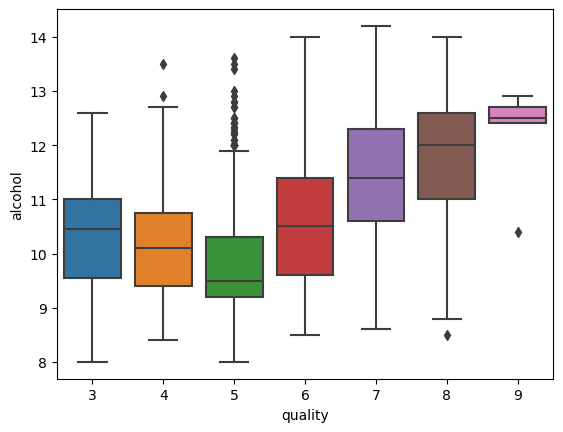

In [27]:
sns.boxplot(data=wine_data, x="quality", y="alcohol")
plt.show()

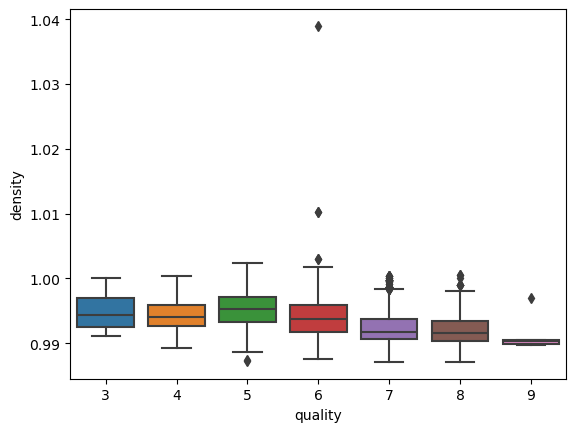

In [29]:
sns.boxplot(data=wine_data, x="quality", y="density")
plt.show()

The huge outlier around quality 6 with density near 1.04 is very suspicious. That wine is probably unusual, maybe very sweet or chemically weird. It may be worth inspecting:

In [40]:
wine_data[wine_data["density"] > 1.02]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
2781,7.8,0.965,0.6,65.8,0.074,8.0,160.0,1.03898,3.39,0.69,11.7,6


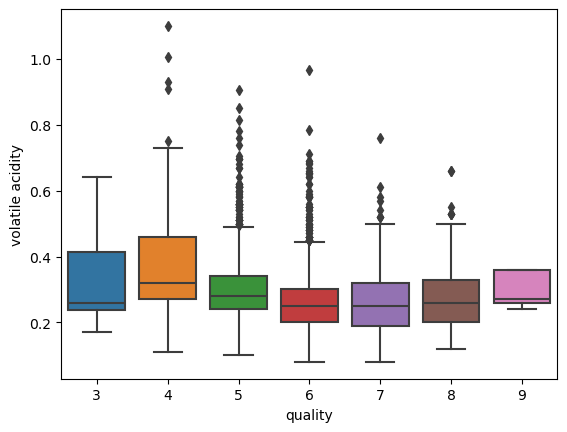

In [30]:
sns.boxplot(data=wine_data, x="quality", y="volatile acidity")
plt.show()

Volatile acidity is probably useful for identifying worse wines, but it does not separate excellent wines as clearly as alcohol or chlorides.

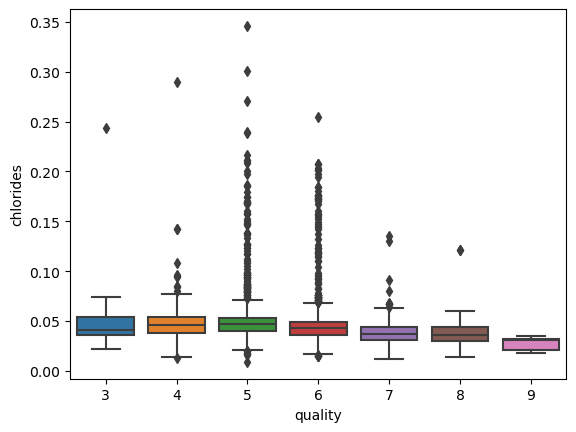

In [31]:
sns.boxplot(data=wine_data, x="quality", y="chlorides")
plt.show()

Chlorides show a clear negative relationship with quality: higher-quality wines tend to have lower chloride concentrations, especially in the top quality classes.

In [41]:
wine_data.groupby("quality")[["alcohol", "density", "volatile acidity", "chlorides"]].agg(
    ["count", "mean", "median", "std"]
)

alcohol                             density                      \
          count       mean median       std   count      mean    median   
quality                                                                   
3            20  10.345000  10.45  1.224089      20  0.994884  0.994425   
4           163  10.152454  10.10  1.003217     163  0.994277  0.994100   
5          1457   9.808840   9.50  0.847065    1457  0.995263  0.995300   
6          2198  10.575372  10.50  1.147776    2198  0.993961  0.993660   
7           880  11.367936  11.40  1.246536     880  0.992452  0.991760   
8           175  11.636000  12.00  1.280138     175  0.992236  0.991640   
9             5  12.180000  12.50  1.013410       5  0.991460  0.990300   

                  volatile acidity                            chlorides  \
              std            count      mean median       std     count   
quality                                                                   
3        0.002831               20  0.333250   0.26  0.140827        20   
4        0.002462              163  0.381227   0.32  0.173463       163   
5        0.002545             1457  0.302011   0.28  0.100066      1457   
6        0.003024             2198  0.260564   0.25  0.088142      2198   
7        0.002768              880  0.262767   0.25  0.091106       880   
8        0.002788              175  0.277400   0.26  0.108029       175   
9        0.003118                5  0.298000   0.27  0.057619         5   

                                    
             mean median       std  
quality                             
3        0.054300  0.041  0.046468  
4        0.050098  0.046  0.025888  
5        0.051546  0.047  0.026496  
6        0.045217  0.043  0.020453  
7        0.038191  0.037  0.010697  
8        0.038314  0.036  0.013164  
9        0.027400  0.031  0.007436

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


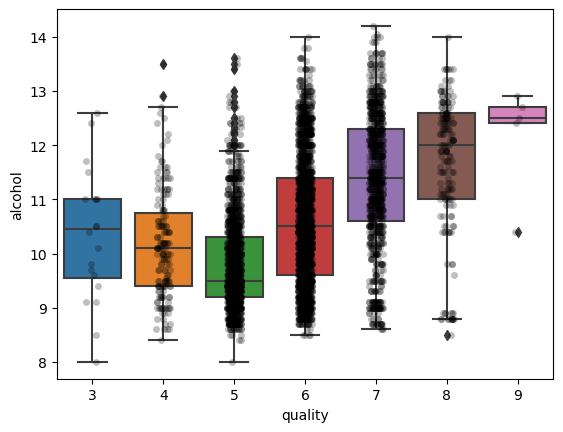

In [43]:
sns.boxplot(data=wine_data, x="quality", y="alcohol")
sns.stripplot(data=wine_data, x="quality", y="alcohol", color="black", alpha=0.25)
plt.show()

The few quality 9 wines in the dataset appear to have high alcohol and low chlorides, but this class is too small to interpret confidently.

High-quality wines tend to combine higher alcohol with lower density and lower chloride levels. This suggests that better-rated wines may be drier, fuller-bodied, less diluted/heavy, and chemically cleaner.

### Data Preprocessing

In [34]:
# Separating features and target
X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

In [36]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (3918, 11)
Testing set: (980, 11)


In [38]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# Convert back to DataFrame for easier interpretation later
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nScaled features sample:")
print(X_train_scaled_df.head())


Scaled features sample:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4665       0.515119         -1.076233     0.227731        0.340419  -0.813688   
1943      -0.669188         -0.288777     0.895832        1.002071  -0.217212   
3399      -1.498203          0.400248    -0.022807        0.184737  -0.400743   
843        0.041396         -0.879369     0.144218       -0.924503  -0.446626   
2580       0.988842          0.203384    -0.607396        2.432407   0.333383   

      free sulfur dioxide  total sulfur dioxide   density        pH  \
4665             0.534065             -0.641932 -0.447041 -0.328261   
1943             0.773947              1.355106  0.903370 -0.061886   
3399            -0.605377             -1.022320 -0.460280  0.404271   
843             -0.125612             -0.879675 -0.304718  0.137896   
2580             0.054300              0.855846  1.883079  0.071302   

      sulphates   alcohol  
4665  -0.702445  1.540371  
1943 

### Baseline Model

In [45]:
# Initialization the Linear Regression model
lr_model = LinearRegression()

In [46]:
# Training the model on the scaled training data
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [47]:
# Making predictions on the scaled testing data
y_pred = lr_model.predict(X_test_scaled)

In [49]:
print(f"Intercept (Bias): {lr_model.intercept_:.4f}")

Intercept (Bias): 5.8714


### Model Evaluation

In [52]:
# Calculating the metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [53]:
print("--- Model Evaluation Metrics ---")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

--- Model Evaluation Metrics ---
MAE:  0.5863
MSE:  0.5690
RMSE: 0.7543
R2:   0.2653


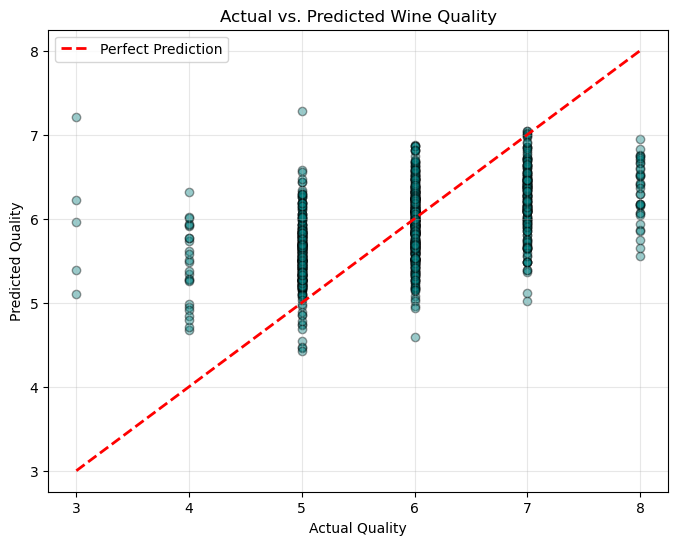

In [61]:
# Visual Evaluation: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal', edgecolors='k')
# Perfect prediction line (where Actual == Predicted)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Wine Quality')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Conclusion:

- The metrics is quite bad
- 0.2653 for R² means the model explan only ~27% of variance
- The model is 'playing safe': predictions are clustres between 4.5-7.5, completely missing the extremes. The model learned that predicting 'average' minimizez overall error enough, but fails to identify truly exceptional or terrible wines
- The class imbalance is the culprit  - with 68% of wines being quality 5-6. the model found 'lazy' solution by predictin around 6 to be 'sort of right' most of the time


The model is not production ready

### Model Improvement

In [63]:
# Strategy 1: Feature Selection - Removing redundant features
features_to_drop = ['free sulfur dioxide', 'density']
X_train_reduced = X_train_scaled_df.drop(columns=features_to_drop)
X_test_reduced = X_test_scaled_df.drop(columns=features_to_drop)

print(f"Features after selection: {list(X_train_reduced.columns)}")
print(f"Shape: {X_train_reduced.shape}")

Features after selection: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']
Shape: (3918, 9)


In [64]:
# Train a new model with reduced features
lr_reduced = LinearRegression()
lr_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = lr_reduced.predict(X_test_reduced)

In [65]:
# Evaluate
mae_reduced = mean_absolute_error(y_test, y_pred_reduced)
rmse_reduced = np.sqrt(mean_squared_error(y_test, y_pred_reduced))
r2_reduced = r2_score(y_test, y_pred_reduced)

print("\n--- Reduced Feature Model ---")
print(f"MAE:  {mae_reduced:.4f}")
print(f"RMSE: {rmse_reduced:.4f}")
print(f"R2:   {r2_reduced:.4f}")


--- Reduced Feature Model ---
MAE:  0.5955
RMSE: 0.7597
R2:   0.2547


In [66]:
# Strategy 2: Regularization (Ridge & Lasso)
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]

print("--- Ridge Regression Results ---")
print(f"{'Alpha':<10} | {'R2':<10} | {'RMSE':<10}")
print("-" * 35)
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    
    r2_r = r2_score(y_test, y_pred_ridge)
    rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    print(f"{a:<10} | {r2_r:<10.4f} | {rmse_r:<10.4f}")

print("\n--- Lasso Regression Results ---")
print(f"{'Alpha':<10} | {'R2':<10} | {'RMSE':<10}")
print("-" * 35)
for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train_scaled, y_train)
    y_pred_lasso = lasso.predict(X_test_scaled)
    
    r2_l = r2_score(y_test, y_pred_lasso)
    rmse_l = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    print(f"{a:<10} | {r2_l:<10.4f} | {rmse_l:<10.4f}")

# Let's look at the Lasso coefficients for alpha=0.01 to see if it dropped any features!
print("\n--- Lasso Coefficients (Alpha=0.01) ---")
lasso_best = Lasso(alpha=0.01)
lasso_best.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns, 
    'Lasso_Coefficient': lasso_best.coef_
})
print(coef_df.sort_values(by='Lasso_Coefficient', ascending=False))

--- Ridge Regression Results ---
Alpha      | R2         | RMSE      
-----------------------------------
0.001      | 0.2653     | 0.7543    
0.01       | 0.2653     | 0.7543    
0.1        | 0.2653     | 0.7543    
1.0        | 0.2652     | 0.7544    
10.0       | 0.2643     | 0.7548    

--- Lasso Regression Results ---
Alpha      | R2         | RMSE      
-----------------------------------
0.001      | 0.2642     | 0.7549    
0.01       | 0.2555     | 0.7593    
0.1        | 0.2165     | 0.7790    
1.0        | -0.0014    | 0.8806    
10.0       | -0.0014    | 0.8806    

--- Lasso Coefficients (Alpha=0.01) ---
                 Feature  Lasso_Coefficient
10               alcohol           0.393402
3         residual sugar           0.167366
5    free sulfur dioxide           0.074760
9              sulphates           0.046793
8                     pH           0.033129
6   total sulfur dioxide          -0.000000
2            citric acid          -0.000791
4              chlorides

- Ridge didn`t help 
- Lasso made things worse

In [68]:
# Strategy 3: Polynomial Features
# Create polynomial features (degree=2 adds squared terms and interactions)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")
print(f"Feature names sample: {poly.get_feature_names_out(X.columns)[:10]}...")

# Train polynomial regression
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("\n--- Polynomial Regression (Degree 2) ---")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R2:   {r2_poly:.4f}")

Original features: 11
Polynomial features: 77
Feature names sample: ['fixed acidity' 'volatile acidity' 'citric acid' 'residual sugar'
 'chlorides' 'free sulfur dioxide' 'total sulfur dioxide' 'density' 'pH'
 'sulphates']...

--- Polynomial Regression (Degree 2) ---
MAE:  0.5670
RMSE: 0.7870
R2:   0.2003


The model`s predictive accuracy has diminished by a drop in explained variance and an increase in error magnitude.  This suggests that the added complexity of polynomial terms did not capture underlying patterns effectively.  
Instead, it likely introduced overfitting

### Summary

In [69]:
# Get coefficients from the baseline model
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

print("--- Baseline Model Coefficients (Sorted) ---")
print(coef_df.sort_values(by='Coefficient', ascending=False))

# Let's also see which features have the strongest impact (absolute value)
print("\n--- Features by Absolute Impact ---")
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
print(coef_df.sort_values(by='Abs_Coefficient', ascending=False))

--- Baseline Model Coefficients (Sorted) ---
                 Feature  Coefficient
3         residual sugar     0.366075
10               alcohol     0.281161
8                     pH     0.090204
5    free sulfur dioxide     0.085366
9              sulphates     0.073719
0          fixed acidity     0.038763
4              chlorides    -0.000577
2            citric acid    -0.007341
6   total sulfur dioxide    -0.010186
1       volatile acidity    -0.194539
7                density    -0.375440

--- Features by Absolute Impact ---
                 Feature  Coefficient  Abs_Coefficient
7                density    -0.375440         0.375440
3         residual sugar     0.366075         0.366075
10               alcohol     0.281161         0.281161
1       volatile acidity    -0.194539         0.194539
8                     pH     0.090204         0.090204
5    free sulfur dioxide     0.085366         0.085366
9              sulphates     0.073719         0.073719
0          fixed acidi

multiple strategies (feature selection, regularization, polynomial features), and none have significantly improved our baseline R2 of 0.2653. This tells us something important: linear regression might not be the right tool for this specific problem.

### Random Forest Regressor

In [70]:
from sklearn.ensemble import RandomForestRegressor

In [71]:
# Initialization the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [72]:
# Training the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [73]:
# Making predictions
y_pred_rf = rf_model.predict(X_test)

In [75]:
# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Evaluation Metrics ---")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")

print("\n--- Comparison ---")
print(f"Linear Regression R2: 0.2653")
print(f"Random Forest R2:     {r2_rf:.4f}")

--- Random Forest Evaluation Metrics ---
MAE:  0.4185
RMSE: 0.5897
R2:   0.5510

--- Comparison ---
Linear Regression R2: 0.2653
Random Forest R2:     0.5510


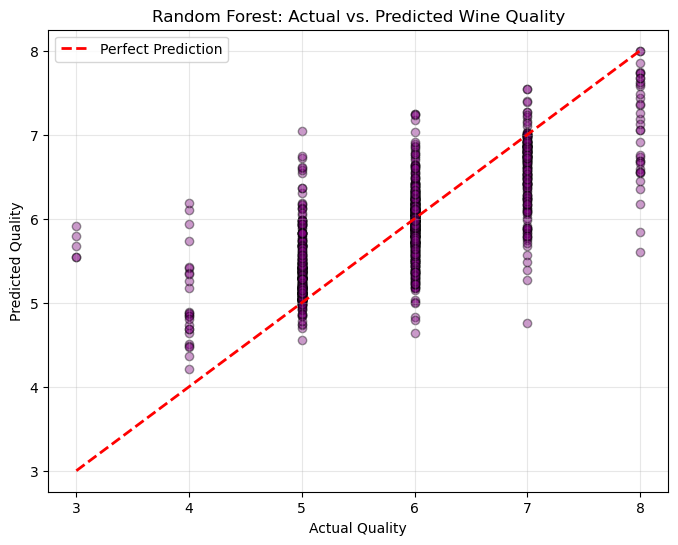

In [79]:
# Visual Evaluation: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='purple', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Random Forest: Actual vs. Predicted Wine Quality')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The model demonstrates a substantial leap in predictive accuracy compared to the baseline linear approach:  
R2 score nearly doubles, indicating a far better fit to the data.

### Gradient Boosting

In [81]:
from sklearn.ensemble import GradientBoostingRegressor

In [107]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=500, 
    learning_rate=0.1, 
    max_depth=7, 
    random_state=42
)

In [108]:
# Train (using unscaled data)
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

In [109]:
# Evaluate
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("--- Gradient Boosting Evaluation Metrics ---")
print(f"MAE:  {mae_gb:.4f}")
print(f"RMSE: {rmse_gb:.4f}")
print(f"R2:   {r2_gb:.4f}")

print("\n--- Model Comparison ---")
print(f"Linear Regression R2:  0.2653")
print(f"Random Forest R2:      0.5510")
print(f"Gradient Boosting R2:  {r2_gb:.4f}")

--- Gradient Boosting Evaluation Metrics ---
MAE:  0.3896
RMSE: 0.5905
R2:   0.5498

--- Model Comparison ---
Linear Regression R2:  0.2653
Random Forest R2:      0.5510
Gradient Boosting R2:  0.5498


### XGBoost

In [111]:
try:
    import xgboost as xgb
    from sklearn.model_selection import GridSearchCV
    
    # Create some interaction features
    wine_data_eng = wine_data.copy()
    wine_data_eng['alcohol_density'] = wine_data_eng['alcohol'] * wine_data_eng['density']
    wine_data_eng['sulfur_ratio'] = wine_data_eng['free sulfur dioxide'] / wine_data_eng['total sulfur dioxide']
    wine_data_eng['acidity_balance'] = wine_data_eng['fixed acidity'] - wine_data_eng['volatile acidity']
    
    X_eng = wine_data_eng.drop('quality', axis=1)
    y_eng = wine_data_eng['quality']
    
    X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
        X_eng, y_eng, test_size=0.2, random_state=42
    )
    
    # XGBoost Regressor
    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    xgb_model.fit(X_train_eng, y_train_eng)
    y_pred_xgb = xgb_model.predict(X_test_eng)
    
    r2_xgb = r2_score(y_test_eng, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test_eng, y_pred_xgb))
    
    print("--- XGBoost with Feature Engineering ---")
    print(f"R2:   {r2_xgb:.4f}")
    print(f"RMSE: {rmse_xgb:.4f}")
    print(f"\nImprovement over RF: {r2_xgb - 0.5510:.4f} R² points")
    
except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")

--- XGBoost with Feature Engineering ---
R2:   0.5522
RMSE: 0.5889

Improvement over RF: 0.0012 R² points


Let`s reframe the problem from regression to Binary Classification

--- Class Distribution ---
quality_binary
0    3838
1    1060
Name: count, dtype: int64

Good wines (1): 21.64%
Not good wines (0): 78.36%

--- Classification Metrics ---
Accuracy:  0.8888
Precision: 0.8512
Recall:    0.6300
F1 Score:  0.7241

--- Classification Report ---
              precision    recall  f1-score   support

    Not Good       0.90      0.97      0.93       753
        Good       0.85      0.63      0.72       227

    accuracy                           0.89       980
   macro avg       0.87      0.80      0.83       980
weighted avg       0.89      0.89      0.88       980



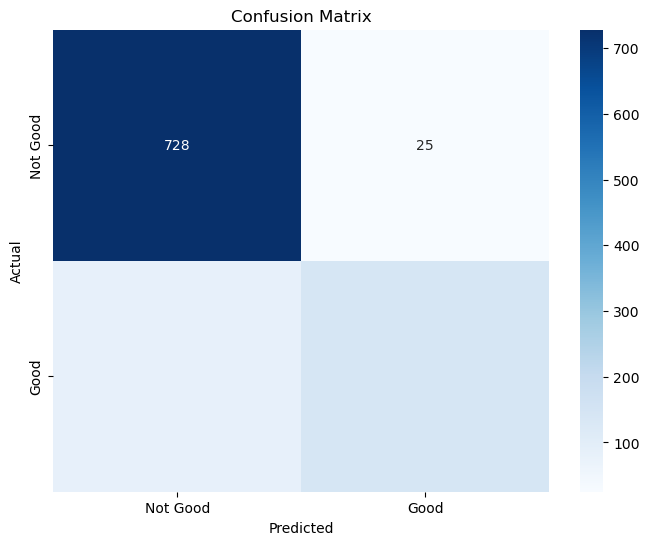


--- Top 5 Most Important Features ---
             Feature  Importance
10           alcohol    0.151618
7            density    0.126949
3     residual sugar    0.089289
4          chlorides    0.088571
1   volatile acidity    0.086456


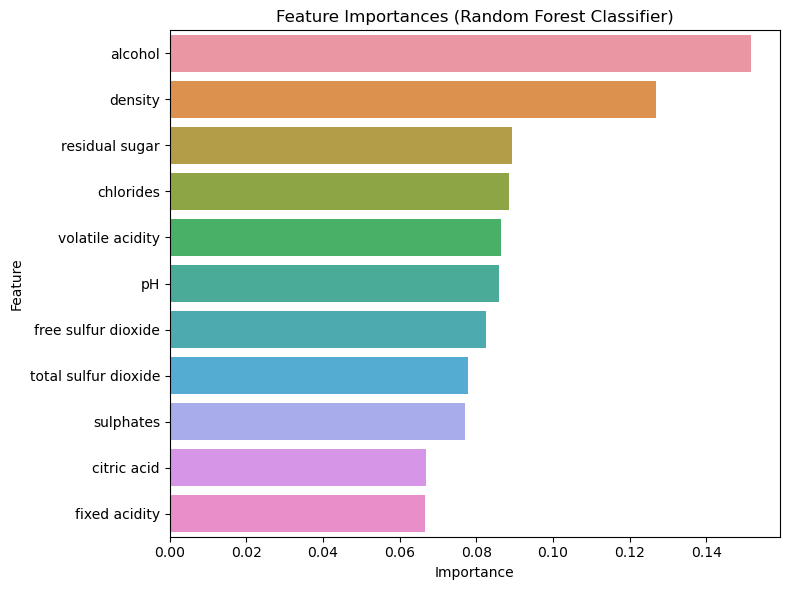

In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Creating binary target variable
wine_data_binary = wine_data.copy()
wine_data_binary['quality_binary'] = (wine_data_binary['quality'] >= 7).astype(int)

print("--- Class Distribution ---")
print(wine_data_binary['quality_binary'].value_counts())
print(f"\nGood wines (1): {(wine_data_binary['quality_binary'] == 1).mean()*100:.2f}%")
print(f"Not good wines (0): {(wine_data_binary['quality_binary'] == 0).mean()*100:.2f}%")

# Data preparation
X_bin = wine_data_binary.drop(['quality', 'quality_binary'], axis=1)
y_bin = wine_data_binary['quality_binary']

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42
)

# Training Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_bin, y_train_bin)

# Predictions
y_pred_bin = rf_clf.predict(X_test_bin)
y_pred_proba = rf_clf.predict_proba(X_test_bin)[:, 1]  # Probability of "good"

# Evaluation with classification metrics
accuracy = accuracy_score(y_test_bin, y_pred_bin)
precision = precision_score(y_test_bin, y_pred_bin)
recall = recall_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)

print("\n--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Not Good', 'Good']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Good', 'Good'],
            yticklabels=['Not Good', 'Good'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
importances = pd.DataFrame({
    'Feature': X_bin.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Most Important Features ---")
print(importances.head())

plt.figure(figsize=(8, 6))
sns.barplot(data=importances, x='Importance', y='Feature')
plt.title('Feature Importances (Random Forest Classifier)')
plt.tight_layout()
plt.show()

In [88]:
cm

array([[728,  25],
       [ 84, 143]], dtype=int64)

The model`s performance indicates a more balanced class distribution compared to the initial state, with one class comprising approximately 78%(Not good wines), and the other around 22%.  
The high accuracy(88.88%) reflects strong overall performance, while the lower recall indicates room for improvement.(we're missing 37% of the actually good wines(84 false negatives out of 227 truly good wines))  
Despite a modest false positive rate, the model's precision suggests reliable confidence when flagging wines as good

Let`s try to improve recall by lowering the decision threshold

In [112]:
# Test different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("--- Threshold Tuning ---")
print(f"{'Threshold':<12} | {'Precision':<12} | {'Recall':<12} | {'F1':<12}")
print("-" * 55)

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    prec = precision_score(y_test_bin, y_pred_thresh)
    rec = recall_score(y_test_bin, y_pred_thresh)
    f1 = f1_score(y_test_bin, y_pred_thresh)
    
    print(f"{thresh:<12.2f} | {prec:<12.4f} | {rec:<12.4f} | {f1:<12.4f}")

--- Threshold Tuning ---
Threshold    | Precision    | Recall       | F1          
-------------------------------------------------------
0.30         | 0.6162       | 0.8062       | 0.6985      
0.40         | 0.7269       | 0.7269       | 0.7269      
0.50         | 0.8371       | 0.6564       | 0.7358      
0.60         | 0.8881       | 0.5595       | 0.6865      
0.70         | 0.9406       | 0.4185       | 0.5793      


Let`s exeriment with a class weight, since our classes not perfectly balanced

In [114]:
# Random Forest with Balanced Class Weights
rf_clf_balanced = RandomForestClassifier(
    n_estimators=500, 
    class_weight='balanced',  # This is the magic parameter
    random_state=42
)

rf_clf_balanced.fit(X_train_bin, y_train_bin)
y_pred_balanced = rf_clf_balanced.predict(X_test_bin)
y_pred_proba_balanced = rf_clf_balanced.predict_proba(X_test_bin)[:, 1]

# Evaluate
accuracy_balanced = accuracy_score(y_test_bin, y_pred_balanced)
precision_balanced = precision_score(y_test_bin, y_pred_balanced)
recall_balanced = recall_score(y_test_bin, y_pred_balanced)
f1_balanced = f1_score(y_test_bin, y_pred_balanced)

print("--- Option 2: Class Weights (Balanced) ---")
print(f"Accuracy:  {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall:    {recall_balanced:.4f}")
print(f"F1 Score:  {f1_balanced:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test_bin, y_pred_balanced, target_names=['Not Good', 'Good']))

--- Option 2: Class Weights (Balanced) ---
Accuracy:  0.8857
Precision: 0.8528
Recall:    0.6123
F1 Score:  0.7128

--- Classification Report ---
              precision    recall  f1-score   support

    Not Good       0.89      0.97      0.93       753
        Good       0.85      0.61      0.71       227

    accuracy                           0.89       980
   macro avg       0.87      0.79      0.82       980
weighted avg       0.88      0.89      0.88       980



In [115]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only (never touch test data!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_bin, y_train_bin)

print("--- SMOTE Applied ---")
print(f"Original training shape: {X_train_bin.shape}")
print(f"After SMOTE: {X_train_smote.shape}")
print(f"Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Train model on balanced data
rf_clf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_smote.fit(X_train_smote, y_train_smote)

# Predict on original test data (not SMOTE'd!)
y_pred_smote = rf_clf_smote.predict(X_test_bin)
y_pred_proba_smote = rf_clf_smote.predict_proba(X_test_bin)[:, 1]

# Evaluate
accuracy_smote = accuracy_score(y_test_bin, y_pred_smote)
precision_smote = precision_score(y_test_bin, y_pred_smote)
recall_smote = recall_score(y_test_bin, y_pred_smote)
f1_smote = f1_score(y_test_bin, y_pred_smote)

print("\n--- Option 3: SMOTE ---")
print(f"Accuracy:  {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall:    {recall_smote:.4f}")
print(f"F1 Score:  {f1_smote:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test_bin, y_pred_smote, target_names=['Not Good', 'Good']))

--- SMOTE Applied ---
Original training shape: (3918, 11)
After SMOTE: (6170, 11)
Class distribution after SMOTE:
quality_binary
0    3085
1    3085
Name: count, dtype: int64

--- Option 3: SMOTE ---
Accuracy:  0.8684
Precision: 0.6914
Recall:    0.7797
F1 Score:  0.7329

--- Classification Report ---
              precision    recall  f1-score   support

    Not Good       0.93      0.90      0.91       753
        Good       0.69      0.78      0.73       227

    accuracy                           0.87       980
   macro avg       0.81      0.84      0.82       980
weighted avg       0.88      0.87      0.87       980



In [118]:
# Comparison table
comparison = pd.DataFrame({
    'Approach': ['Original (50% threshold)', 'Class Weights', 'SMOTE'],
    'Accuracy': [accuracy, accuracy_balanced, accuracy_smote],
    'Precision': [precision, precision_balanced, precision_smote],
    'Recall': [recall, recall_balanced, recall_smote],
    'F1 Score': [f1, f1_balanced, f1_smote]
})

print("\n" + "="*70)
print("GRAND COMPARISON: Handling Imbalanced Data")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)


GRAND COMPARISON: Handling Imbalanced Data
                Approach  Accuracy  Precision   Recall  F1 Score
Original (50% threshold)  0.888776   0.851190 0.629956  0.724051
           Class Weights  0.885714   0.852761 0.612335  0.712821
                   SMOTE  0.868367   0.691406 0.779736  0.732919


### Summary:


Original model(50% threshold):  

- High Accuracy(88.9%): The model playing safe, predicting 'No good' most of the time
- Hight Precision(85.1%): When it says 'Good', it is usually correct
- Low recall(63%): Missing a lot of actually good wines

Use case: Conservative approach - minimize false alarms

Class Weights: Shows nearly identical to original model results

SMOTE:  

- Lower accuracy (86.8%): The model is now predicting "Good" more often, so it makes more mistakes overall
- Much lower precision (69.1%): More false positives—calling mediocre wines "Good"
- Much higher recall (78.0%): Catching significantly more good wines
- Highest F1 (0.733): Best balance between precision and recall

Use case: When catching all good wines is more important than avoiding false positives